### Import Dependecies

In [1]:
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage, SystemMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI
import openai

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message

from langsmith import traceable

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import Filter, FieldCondition, MatchValue, VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

### Exploring Native OpenAI Tool Calling

In [2]:
from openai import OpenAI

In [3]:
client = OpenAI()

In [4]:
response = openai.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": """You are a shopping assistant that answers customer questions about products currently in stock.

## Instructions

- Use the available tools to answer product questions. Do not fabricate product details.
- When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
- When describing products, include detailed specifications in bullet points.
- If tools return no relevant results, tell the customer and ask them to refine their query.
- Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they're interested in.
- In references, include every chunk that contributed to your answer with the chunk id and product name.
- Refer to retrieved data as "available products", never as "context".
- Try answering queries that are not precise, if specific names or brands are missing apply broad searches.
"""},
        {"role": "user", "content": "Can I get a tablet for my kid, a watch for me a laptop for my wife and a waterproof speaker for our party next week?"}
    ],
    tools=[
        {
            "type": "function",
            "function": {
                "name": "get_formatted_item_context",
                "description": "Get the top k context, each representing an inventory item for a given query",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "query": {"type": "string", "description": "The query to get the top k context for"},
                        "top_k": {"type": "integer", "description": "The number of context chunks to retrieve, works best with 5 or more"}
                    },
                    "required": ["query"]
                }
            }
        }
    ],
    tool_choice="required"
)

In [5]:
response

ChatCompletion(id='chatcmpl-DcZfY3aHb0wvUokXdRyC0PWzDWYlH', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_f7ugPserXUlTDqDutjvvWldG', function=Function(arguments='{"query": "tablet for kids", "top_k": 3}', name='get_formatted_item_context'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_vmazUeZEcAffvzfJEsrwbO3k', function=Function(arguments='{"query": "watch", "top_k": 3}', name='get_formatted_item_context'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_I1Gq30Awk4JIZtRbBjmOi0SX', function=Function(arguments='{"query": "laptop", "top_k": 3}', name='get_formatted_item_context'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_XyapJbqYQ5BwPBDKGmgHb2cP', function=Function(arguments='{"query": "waterproof speaker", "top_k": 3}', name='

### Exploring LangChain Tool Calling

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

In [7]:
@tool
def dummy_tool(a: str, b: str) -> str:

    """Concatenate two strings.
    
    Args:
        a: The first string to concatenate
        b: The second string to concatenate
    
    Returns:
        A string of the two strings concatenated.
    """

    return f"Hello {a} and {b}"

In [8]:
llm = ChatOpenAI(model="gpt-4.1-mini")
llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto"
)

In [9]:
response = llm_with_tools.invoke("Use dummy tool to concatenate two random words")

In [10]:
response

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 85, 'total_tokens': 104, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_627d74211b', 'id': 'chatcmpl-DcZhg0HcSRjLNQYOyMXSOjR2T4BQO', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dfe30-61aa-7052-ac05-7bdce1ee3b08-0', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'sun', 'b': 'flower'}, 'id': 'call_Mw4DXq1RPVkm2xZg95kxyN7h', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 85, 'output_tokens': 19, 'total_tokens': 104, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
response.response_metadata["token_usage"]

{'completion_tokens': 19,
 'prompt_tokens': 85,
 'total_tokens': 104,
 'completion_tokens_details': {'accepted_prediction_tokens': 0,
  'audio_tokens': 0,
  'reasoning_tokens': 0,
  'rejected_prediction_tokens': 0},
 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}

### Agent Graph with Loopback from Tools (ReAct Agent)

### Define Retirieval Tool

In [12]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):    
    response = openai.embeddings.create(
        input=text,
        model=model,
    )

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    qdrant_client = QdrantClient(url="http://localhost:6333")

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1,1])),
        limit=k
    )

    retrieved_context_ids = []
    retieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


@traceable(
    name="format_retrieved_context",
    run_type="prompt"
)
def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context


@tool
def get_formatted_item_context(query: str, top_k: int = 5) -> str:

    """Get the top k context, each representing an inventory item for a given query.
    
    Args:
        query: The query to get the top k context for
        top_k: The number of context chunks to retrieve, works best with 5 or more
    
    Returns:
        A string of the top k context chunks with IDs and average ratings prepending each chunk, each representing an inventory item for a given query.
    """

    context = retrieve_data(query, top_k)
    formatted_context = process_context(context)

    return formatted_context

### State and Pydantic Models for Structured Outputs

In [13]:
class RAGUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Short description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")
    references: list[RAGUsedContext] = Field(description="List of items used to answer the question")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: Annotated[List[RAGUsedContext], add] = []

In [14]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def agent_node(state: State) -> dict:

    prompt_template = """You are a shopping assistant that answers customer questions about products currently in stock.

## Instructions

- Use the available tools to answer product questions. Do not fabricate product details.
- When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
- When describing products, include detailed specifications in bullet points.
- If tools return no relevant results, tell the customer and ask them to refine their query.
- Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they're interested in.
- In references, include every chunk that contributed to your answer with the chunk id and product name.
- Refer to retrieved data as "available products", never as "context".
- Try answering queries that are not precise, if specific names or brands are missing apply broad searches.
"""

    template = Template(prompt_template)

    prompt = template.render()

    messages = state.messages

    llm = ChatOpenAI(model="gpt-4.1-mini")
    llm_with_tools = llm.bind_tools(
        [get_formatted_item_context, FinalResponse],
        tool_choice="auto"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *messages
        ]
    )

    final_answer = False
    answer = ""
    references = []

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                references.extend(tool_call.get("args").get("references"))

    return {
        "messages": [response],
        "iteration": state.iteration + 1,
        "answer": answer,
        "final_answer": final_answer,
        "references": references
    }


In [15]:
def tool_router(state: State) -> dict:

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

### User Intent Router Node

In [16]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str

In [17]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

## Instructions

- Determine whether the question is about products, inventory, or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not related to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant: no - about store policy, not product information
"""

    template = Template(prompt_template)

    prompt = template.render()
    messages = state.messages

    conversation = []

    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        response_model=IntentRouterResponse
    )
 
    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [18]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

In [19]:
workflow = StateGraph(State)

tools = [get_formatted_item_context]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

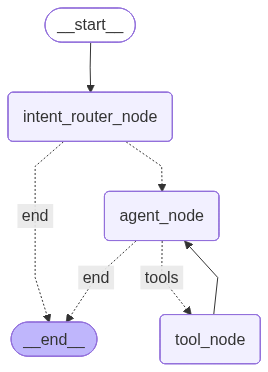

In [20]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
initial_state = {
    "messages": [{"role": "user", "content": "Can I get a tablet for my kid, a watch for me a laptop for my wife and a waterproof speaker for our party next week?"}]
}

In [22]:
result = graph.invoke(initial_state)

In [23]:
result

{'messages': [{'role': 'user',
   'content': 'Can I get a tablet for my kid, a watch for me a laptop for my wife and a waterproof speaker for our party next week?'},
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 400, 'total_tokens': 514, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_49f260aaf7', 'id': 'chatcmpl-DcZidw7CzZo2iN1K7iVjq7oWiwUHp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dfe31-4be4-73b0-b91e-ba44a2274fc3-0', tool_calls=[{'name': 'get_formatted_item_context', 'args': {'query': 'tablet for kids', 'top_k': 3}, 'id': 'call_AjPN0pW23cedakniXivf6Fdf', 'type': 'tool_call'}, {'name': 'get_f

In [24]:
print(result["answer"])

Here are some product options for your needs:

Tablet for your kid:
- ROWT Tablet for Kids, 10 inch, 2GB RAM 32GB ROM, Android 11, 6000mAh battery, kid-proof case, parental controls, educational content, and HD screen.
- COOPERS 7 inch Kids Tablet with Android 11, 2GB RAM, 32GB ROM, parental controls, dual cameras, and long-lasting battery.

Watch for you:
- WalkerFit A2 Pro Smart Watch for Men, fitness tracker with heart rate, blood pressure, and oxygen monitors, 1.4" touch screen, waterproof (IP67), call and message notifications.
- Blood Pressure Monitor Smart Watch with fitness tracking, waterproof, big screen, supports calls and texts.

Laptop for your wife:
- Kuosdaz Travel Laptop Backpack for Women, fits 15.6 inch laptops, USB charging port, large capacity, anti-theft pockets.
- Focdod Laptop Backpack Women Work Bookbag, 15.6 inch laptop compartment, USB charging port, multiple compartments, water resistant.

Waterproof speakers for the party:
- SYOYOC Waterproof Bluetooth Speak